In [1]:
from util import * 

# Specifying target qoi and grid spacing 
target_qoi, grid_spacing = 'U', 0.005

# Loading data dictionary
scaler, data_dict, ratio, train_tuple, x_partitions = get_data_dict(target_qoi=target_qoi, grid_spacing=grid_spacing) 

# Extracting high-fidelity training data 
Xtrain, Ytrain = train_tuple

# Storing training and testing data
Xtest, Ytest = data_dict[4]['X'], data_dict[4][target_qoi]
data_dict[4]['X'], data_dict[4][target_qoi] = Xtrain, Ytrain

temp_X = np.copy(scaler.inverse_transform(Xtest))
temp_X[:,1] = -temp_X[:,1]
temp_Y = np.copy(Ytest)

# Training low-fidelity surrogate models with KNN 
train_features, test_features = generate_features(data_dict, Xtrain, Xtest, n_neighbors = 10)

# Getting the 177micrometer testing predictions 
test_pred = test_features[:,-1]

# Obtaining the minimum and maximum velocity values 
vmin = min(test_pred.min(), data_dict[3][target_qoi].min())
vmax = max(test_pred.max(), data_dict[3][target_qoi].max())

Training KNN Models...


100%|██████████| 4/4 [00:00<00:00,  6.19it/s]


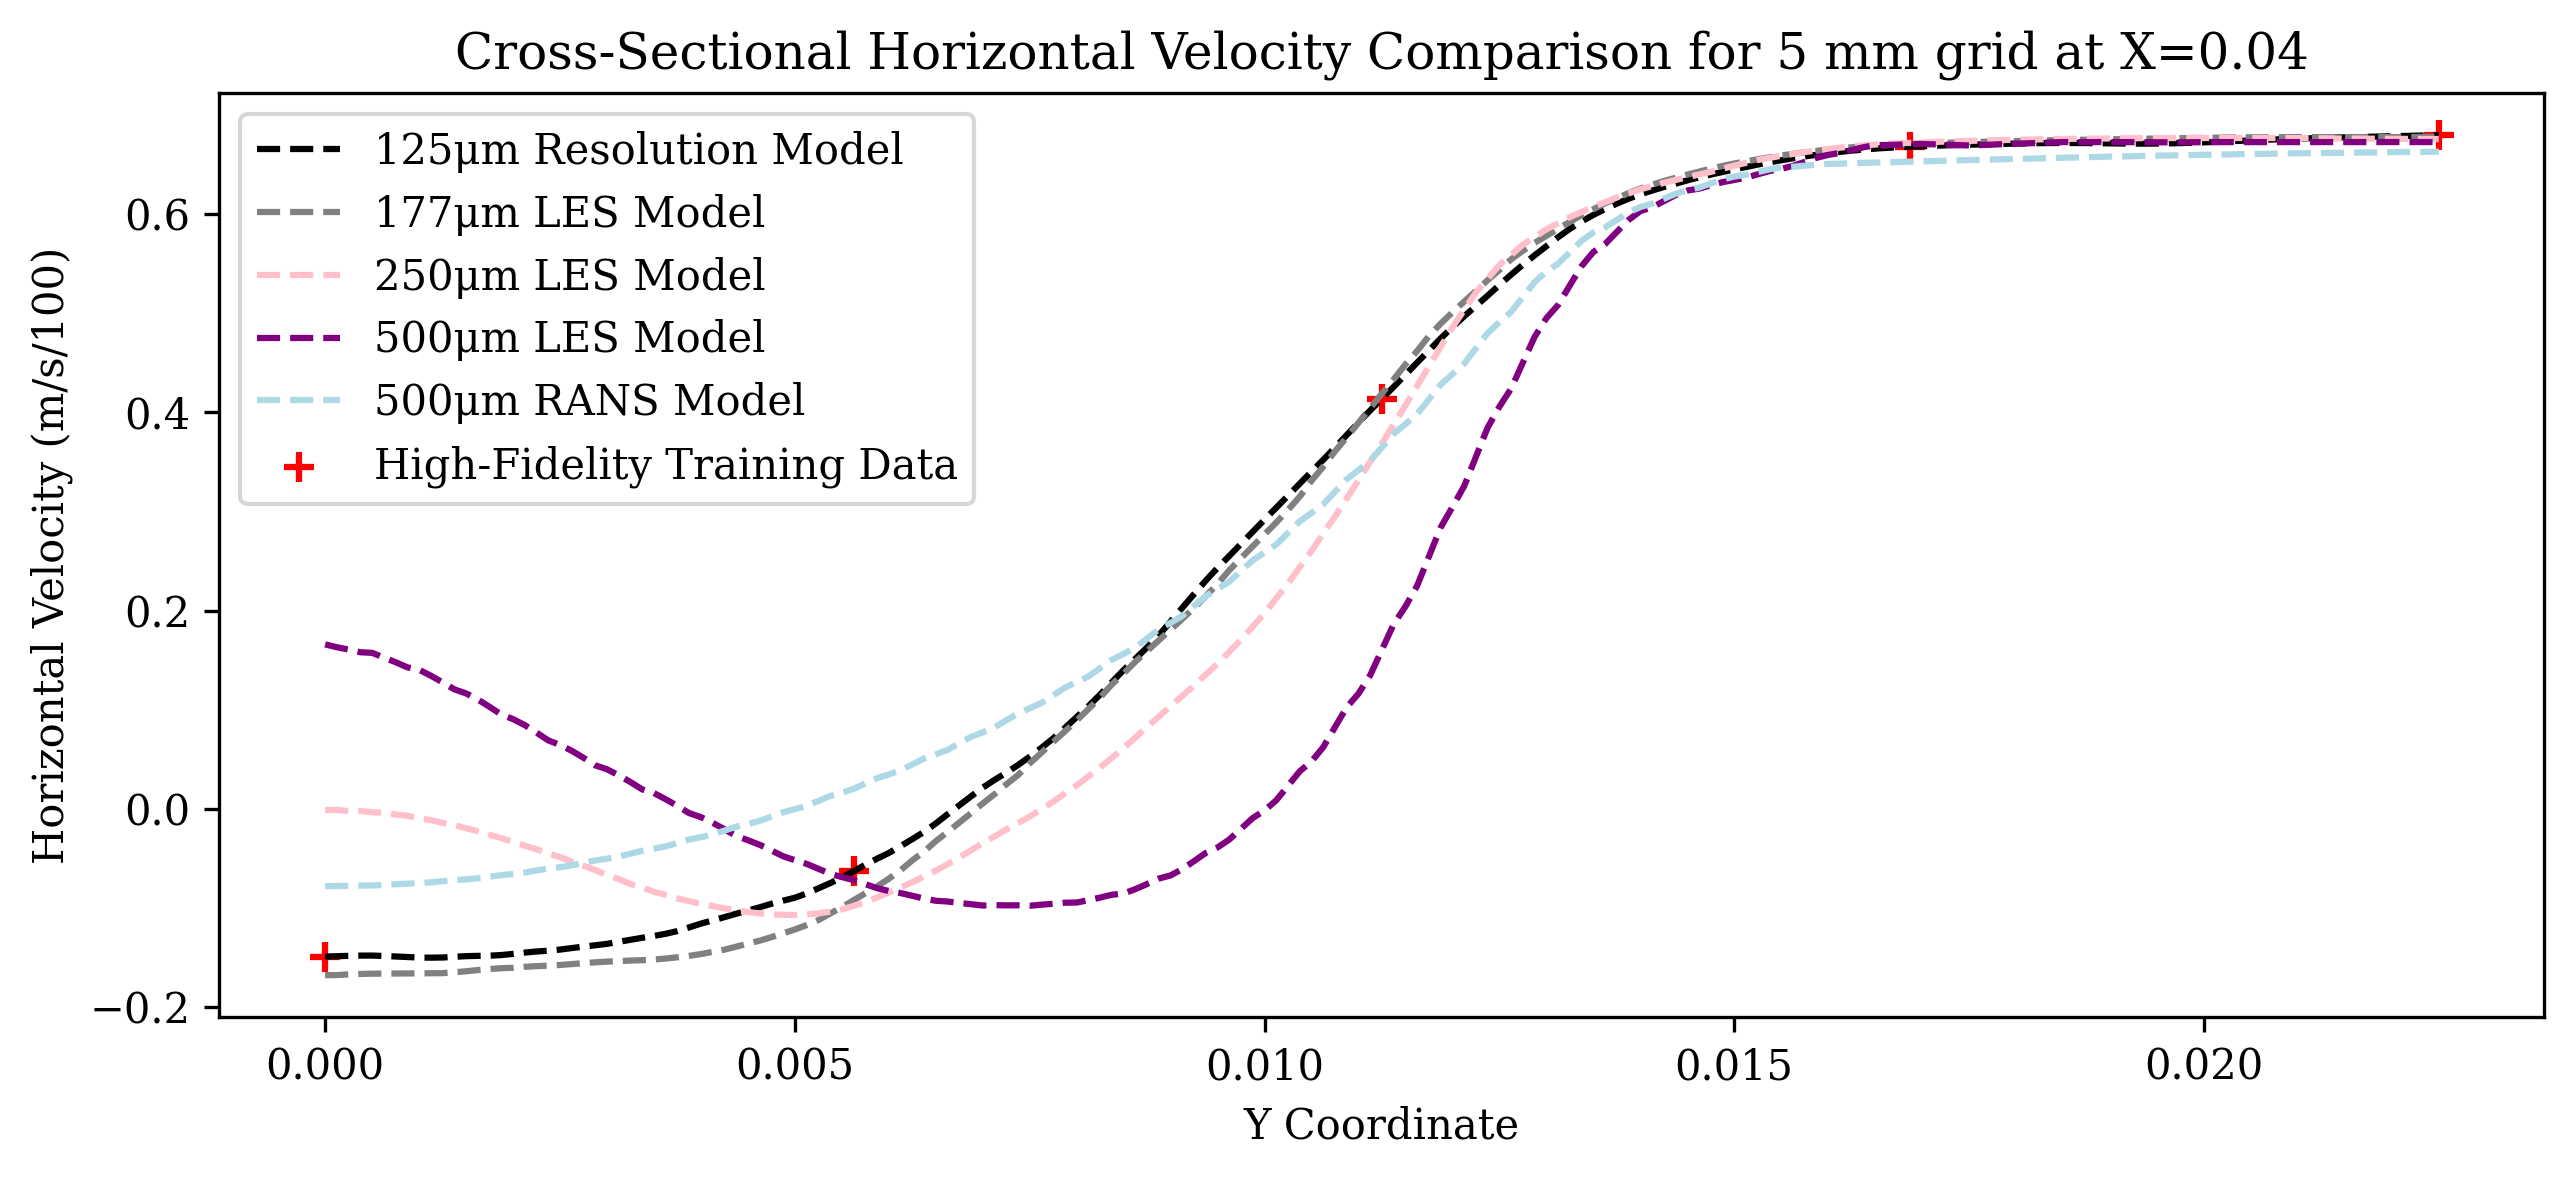

In [2]:
cs_criterion = (jnp.abs(scaler.inverse_transform(Xtest)[:,0] - 0.04) <= 1e-4) # & (scaler.inverse_transform(Xtest)[:,0] <= (x_partitions-1) * grid_spacing)
Xcs, Ycs, Fcs = Xtest[cs_criterion,:], Ytest[cs_criterion], test_features[cs_criterion, :]

plt.figure(figsize=(10,4), dpi = 300)
plt.plot(scaler.inverse_transform(Xcs)[:,1], Ycs, label = "125μm Resolution Model", color = 'black', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xcs)[:,1], test_features[cs_criterion,5], label = "177μm LES Model", color = 'gray', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xcs)[:,1], test_features[cs_criterion,4], label = "250μm LES Model", color = 'pink', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xcs)[:,1], test_features[cs_criterion,3], label = "500μm LES Model", color = 'purple', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xcs)[:,1], test_features[cs_criterion,2], label = "500μm RANS Model", color = 'lightblue', linestyle = 'dashed')
plt.scatter(scaler.inverse_transform(Xtrain)[jnp.abs(scaler.inverse_transform(Xtrain)[:,0] - 0.04) <= 1e-4, 1], Ytrain[jnp.abs(scaler.inverse_transform(Xtrain)[:,0] - 0.04) <= 1e-4], marker = '+', color = 'red', label = 'High-Fidelity Training Data', s = 50.0)
plt.xlabel("Y Coordinate")
plt.ylabel("Horizontal Velocity (m/s/100)")
plt.title("Cross-Sectional Horizontal Velocity Comparison for %d mm grid at X=0.04" % (grid_spacing * 1000))
plt.legend()

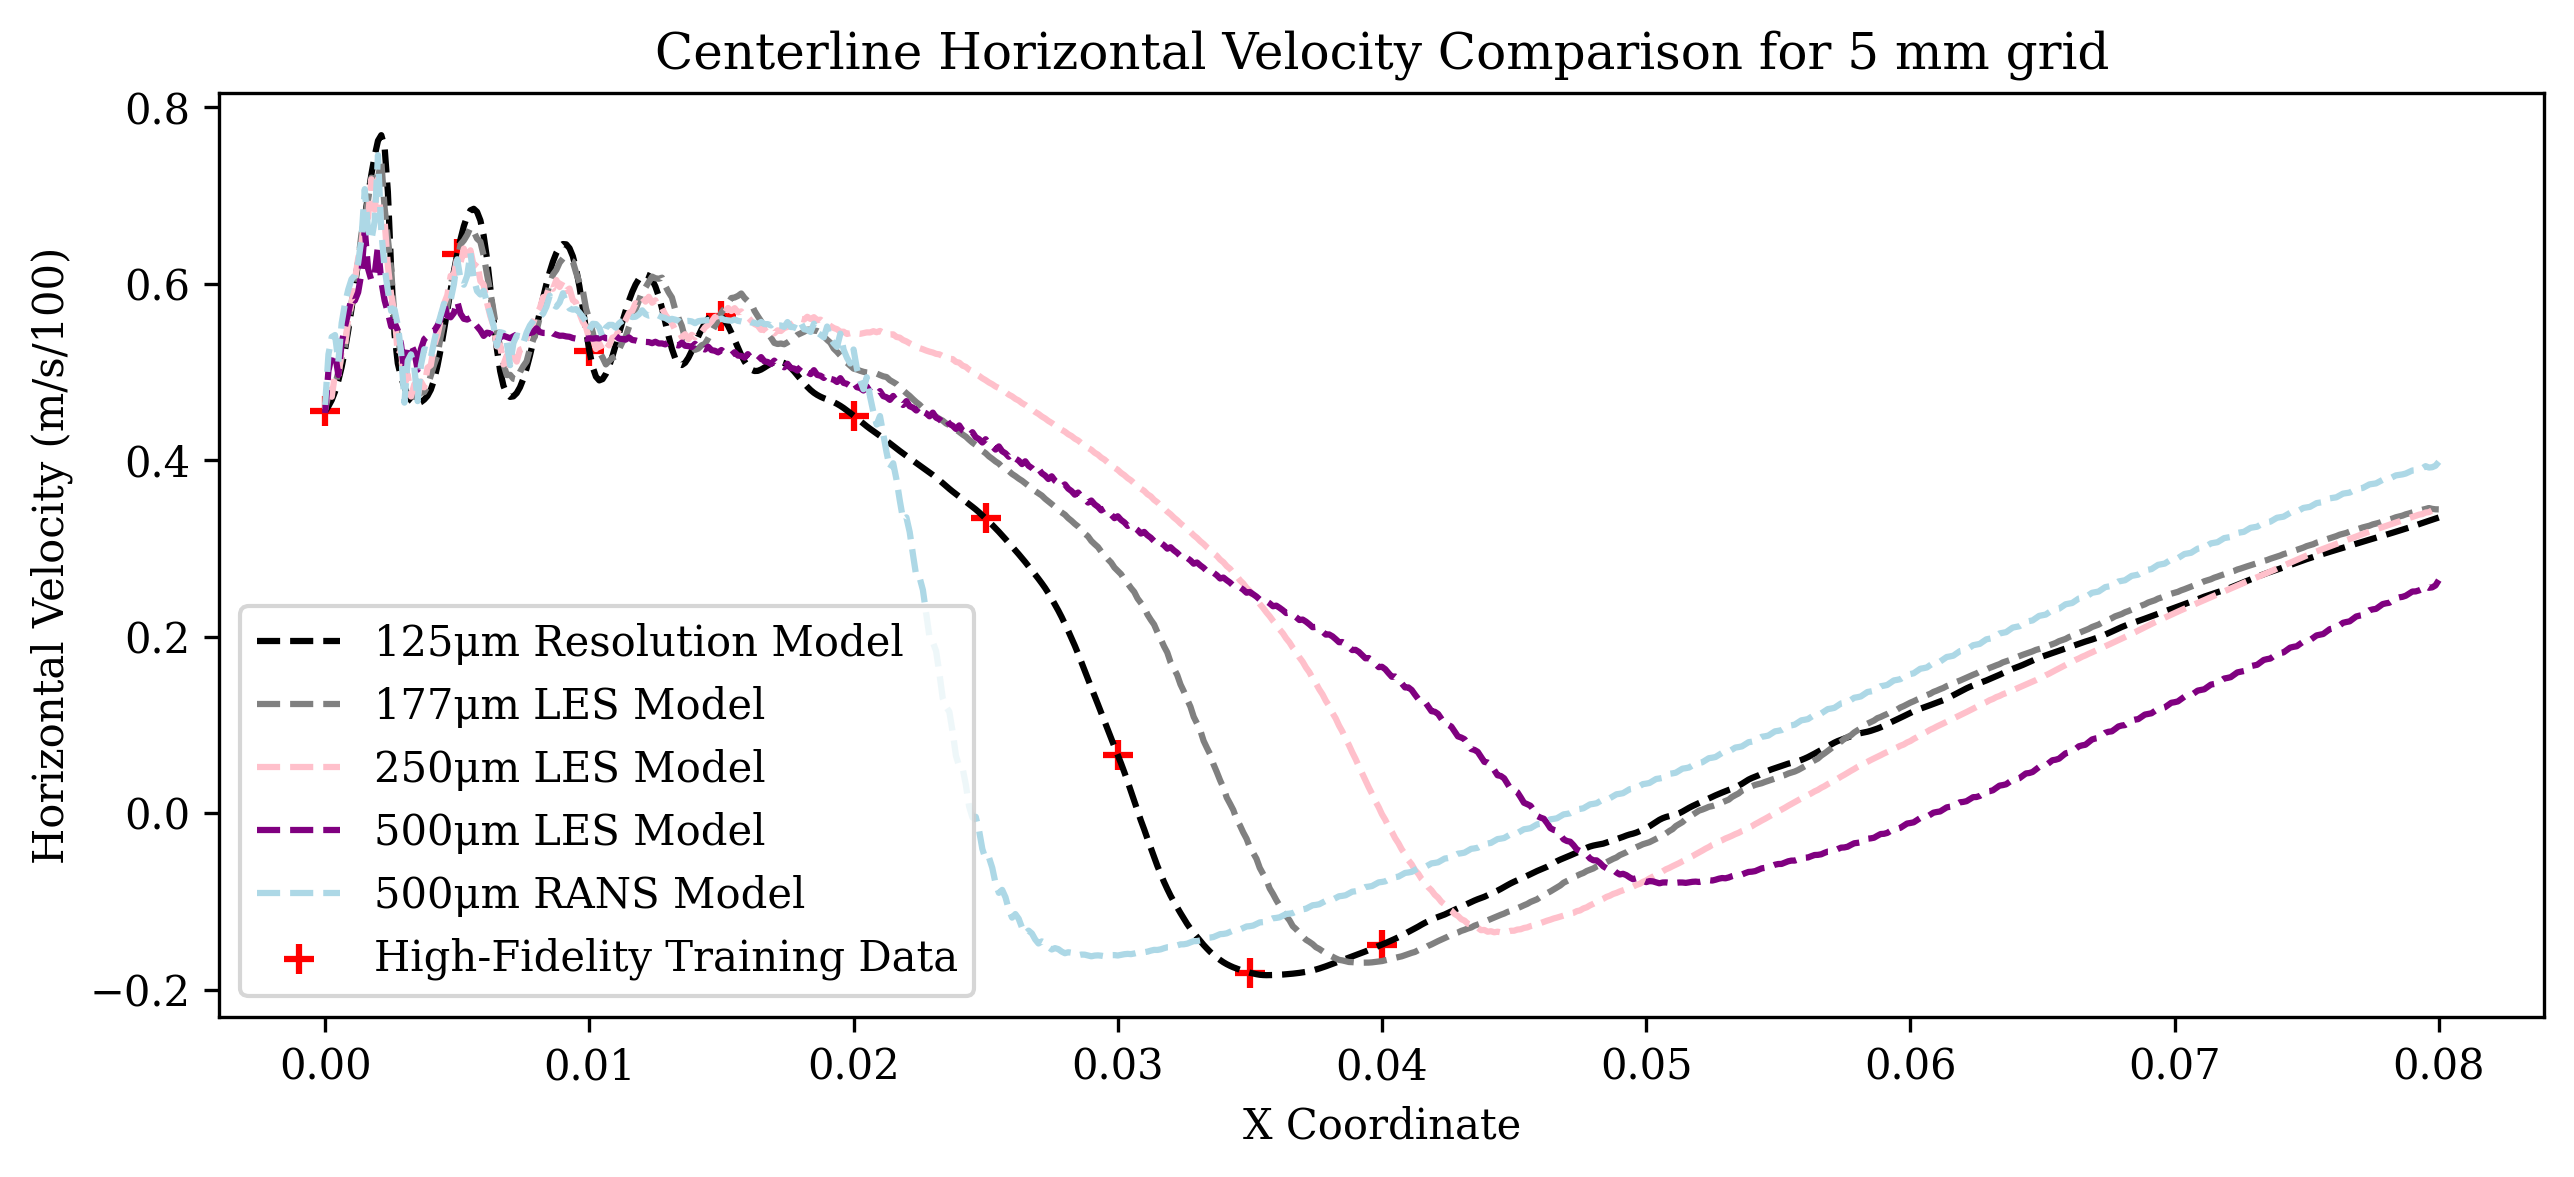

In [3]:
jet_criterion = (Xtest[:,1] == Xtest[:,1].min()) # & (scaler.inverse_transform(Xtest)[:,0] <= (x_partitions-1) * grid_spacing)
Xjet, Yjet, Fjet = Xtest[jet_criterion,:], Ytest[jet_criterion], test_features[jet_criterion, :]

plt.figure(figsize=(10,4), dpi = 300)
plt.plot(scaler.inverse_transform(Xjet)[:,0], Yjet, label = "125μm Resolution Model", color = 'black', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xjet)[:,0], test_features[jet_criterion,5], label = "177μm LES Model", color = 'gray', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xjet)[:,0], test_features[jet_criterion,4], label = "250μm LES Model", color = 'pink', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xjet)[:,0], test_features[jet_criterion,3], label = "500μm LES Model", color = 'purple', linestyle = 'dashed')
plt.plot(scaler.inverse_transform(Xjet)[:,0], test_features[jet_criterion,2], label = "500μm RANS Model", color = 'lightblue', linestyle = 'dashed')
plt.scatter(scaler.inverse_transform(Xtrain)[Xtrain[:,1] == Xtrain[:,1].min(), 0], Ytrain[Xtrain[:,1] == Xtrain[:,1].min()], marker = '+', color = 'red', label = 'High-Fidelity Training Data', s = 50.0)
plt.xlabel("X Coordinate")
plt.ylabel("Horizontal Velocity (m/s/100)")
plt.title("Centerline Horizontal Velocity Comparison for %d mm grid" % (grid_spacing * 1000))
plt.legend()

In [4]:
F_train = np.copy(train_features)
F_test = np.copy(test_features)

In [5]:
import pickle 
load_params = False

In [ ]:
# Creating a high-fidelity NARGP model with multi-fidelity features
nargp = GP(jnp.hstack((Xtrain, train_features[:,-1].reshape(-1,1))), Ytrain, NARGP_RBF, Zero, noise_var = 1e-6, epsilon = 1e-12, max_cond = 1e5, calibrate=True)
if not load_params:
    nargp_optimizer = ADAM(nargp, neg_mll, beta1 = 0.9, beta2=0.999)
    nargp_optimizer.run(1e-2, 15000, ['k_param', 'm_param', 'noise_var'])
else:
    with open("models/nargp_params.pkl", "rb") as infile:
        nargp.set_params(pickle.load(infile))

Calibrated white noise variance: 1.0000e-06


  5%|▌         | 509/10000 [00:01<00:24, 391.68it/s, Loss: -7.4797e+01]


KeyboardInterrupt: 

In [ ]:
# Creating a high-fidelity MAGPI model with multi-fidelity features
magpi_model = GP(F_train, Ytrain, RBF, Linear, noise_var = 1e-6, epsilon = 1e-12, max_cond = 1e5, calibrate=True)
if True:
    optimizer = ADAM(magpi_model, neg_mll, beta1 = 0.9, beta2=0.999)
    optimizer.run(1e-2, 15000, ['k_param', 'm_param', 'noise_var'])
else:
    with open("models/hk_params.pkl", "rb") as infile:
        magpi_model.set_params(pickle.load(infile))

Calibrated white noise variance: 1.0000e-06


 44%|████▍     | 6641/15000 [00:12<00:16, 505.56it/s, Loss: -1.3315e+02]

In [10]:
# Training a Kennedy O'Hagan autoregressive estimator on just the top two levels of fidelity
delta = DeltaGP(Xtrain, Ytrain, train_features[:,-1], RBF, Zero,  max_cond = 1e5, calibrate = True, noise_var = 1e-6, epsilon = 1e-12)
if not load_params:
    koh_optimizer = ADAM(delta, delta_neg_mll, beta1 = 0.9, beta2 = 0.999)
    koh_optimizer.run(1e-2, 5000, ['rho', 'k_param', 'm_param', 'noise_var'])
else:
    with open("models/koh_params.pkl", "rb") as infile:
        delta.set_params(pickle.load(infile))

Calibrated white noise variance: 1.0000e-06


 20%|█▉        | 996/5000 [00:02<00:08, 464.17it/s, Loss: -5.8063e+01]


KeyboardInterrupt: 

In [11]:
# Training a high-fidelity Kriging model 
kr_model = GP(Xtrain, Ytrain, RBF, Constant, noise_var = 1e-6, epsilon = 1e-12, max_cond = 1e5, calibrate=True)
if not load_params:
    kr_optimizer = ADAM(kr_model, neg_mll, beta1 = 0.9, beta2=0.999)
    kr_optimizer.run(1e-1, 5000, ['k_param', 'm_param'])
else:
    with open("models/kr_params.pkl", "rb") as infile:
        kr_model.set_params(pickle.load(infile))

Calibrated white noise variance: 1.0000e-06


100%|██████████| 5000/5000 [00:07<00:00, 633.89it/s, Loss: -2.8794e+01]


In [12]:
# # # Saving parameters (if uncommented)
with open("models/nargp.pkl", "wb") as outfile: 
    pickle.dump(nargp,outfile)

with open("models/magpi.pkl", "wb") as outfile:
    pickle.dump(magpi_model, outfile)

with open("models/koh.pkl", "wb") as outfile:
    pickle.dump(delta, outfile)

with open("models/kr.pkl", "wb") as outfile:
    pickle.dump(kr_model, outfile)

In [18]:
from sklearn.metrics import mean_squared_error as MSE 
hk_mean, hk_var = magpi_model.predict(F_test, full_cov = False) 

# Making predictions using the kennedy o'hagan estimator
delta_mean, delta_var = delta.predict(Xtest, full_cov = False)
koh_mean = delta.p['rho'] * test_features[:,-1] + delta_mean 
koh_var = delta_var 

# Making predictions using the nargp estimator
nargp_mean, nargp_var = nargp.predict(jnp.hstack((Xtest, test_features[:,-1].reshape(-1,1))), full_cov=False)

# Making predictions using the high-fidelity Kriging model
kr_mean, kr_var = kr_model.predict(Xtest, full_cov = False)

# Specifying only the training data within the grid 
grid_criterion = (Xtest[:,0] <= (x_partitions-1) * grid_spacing)

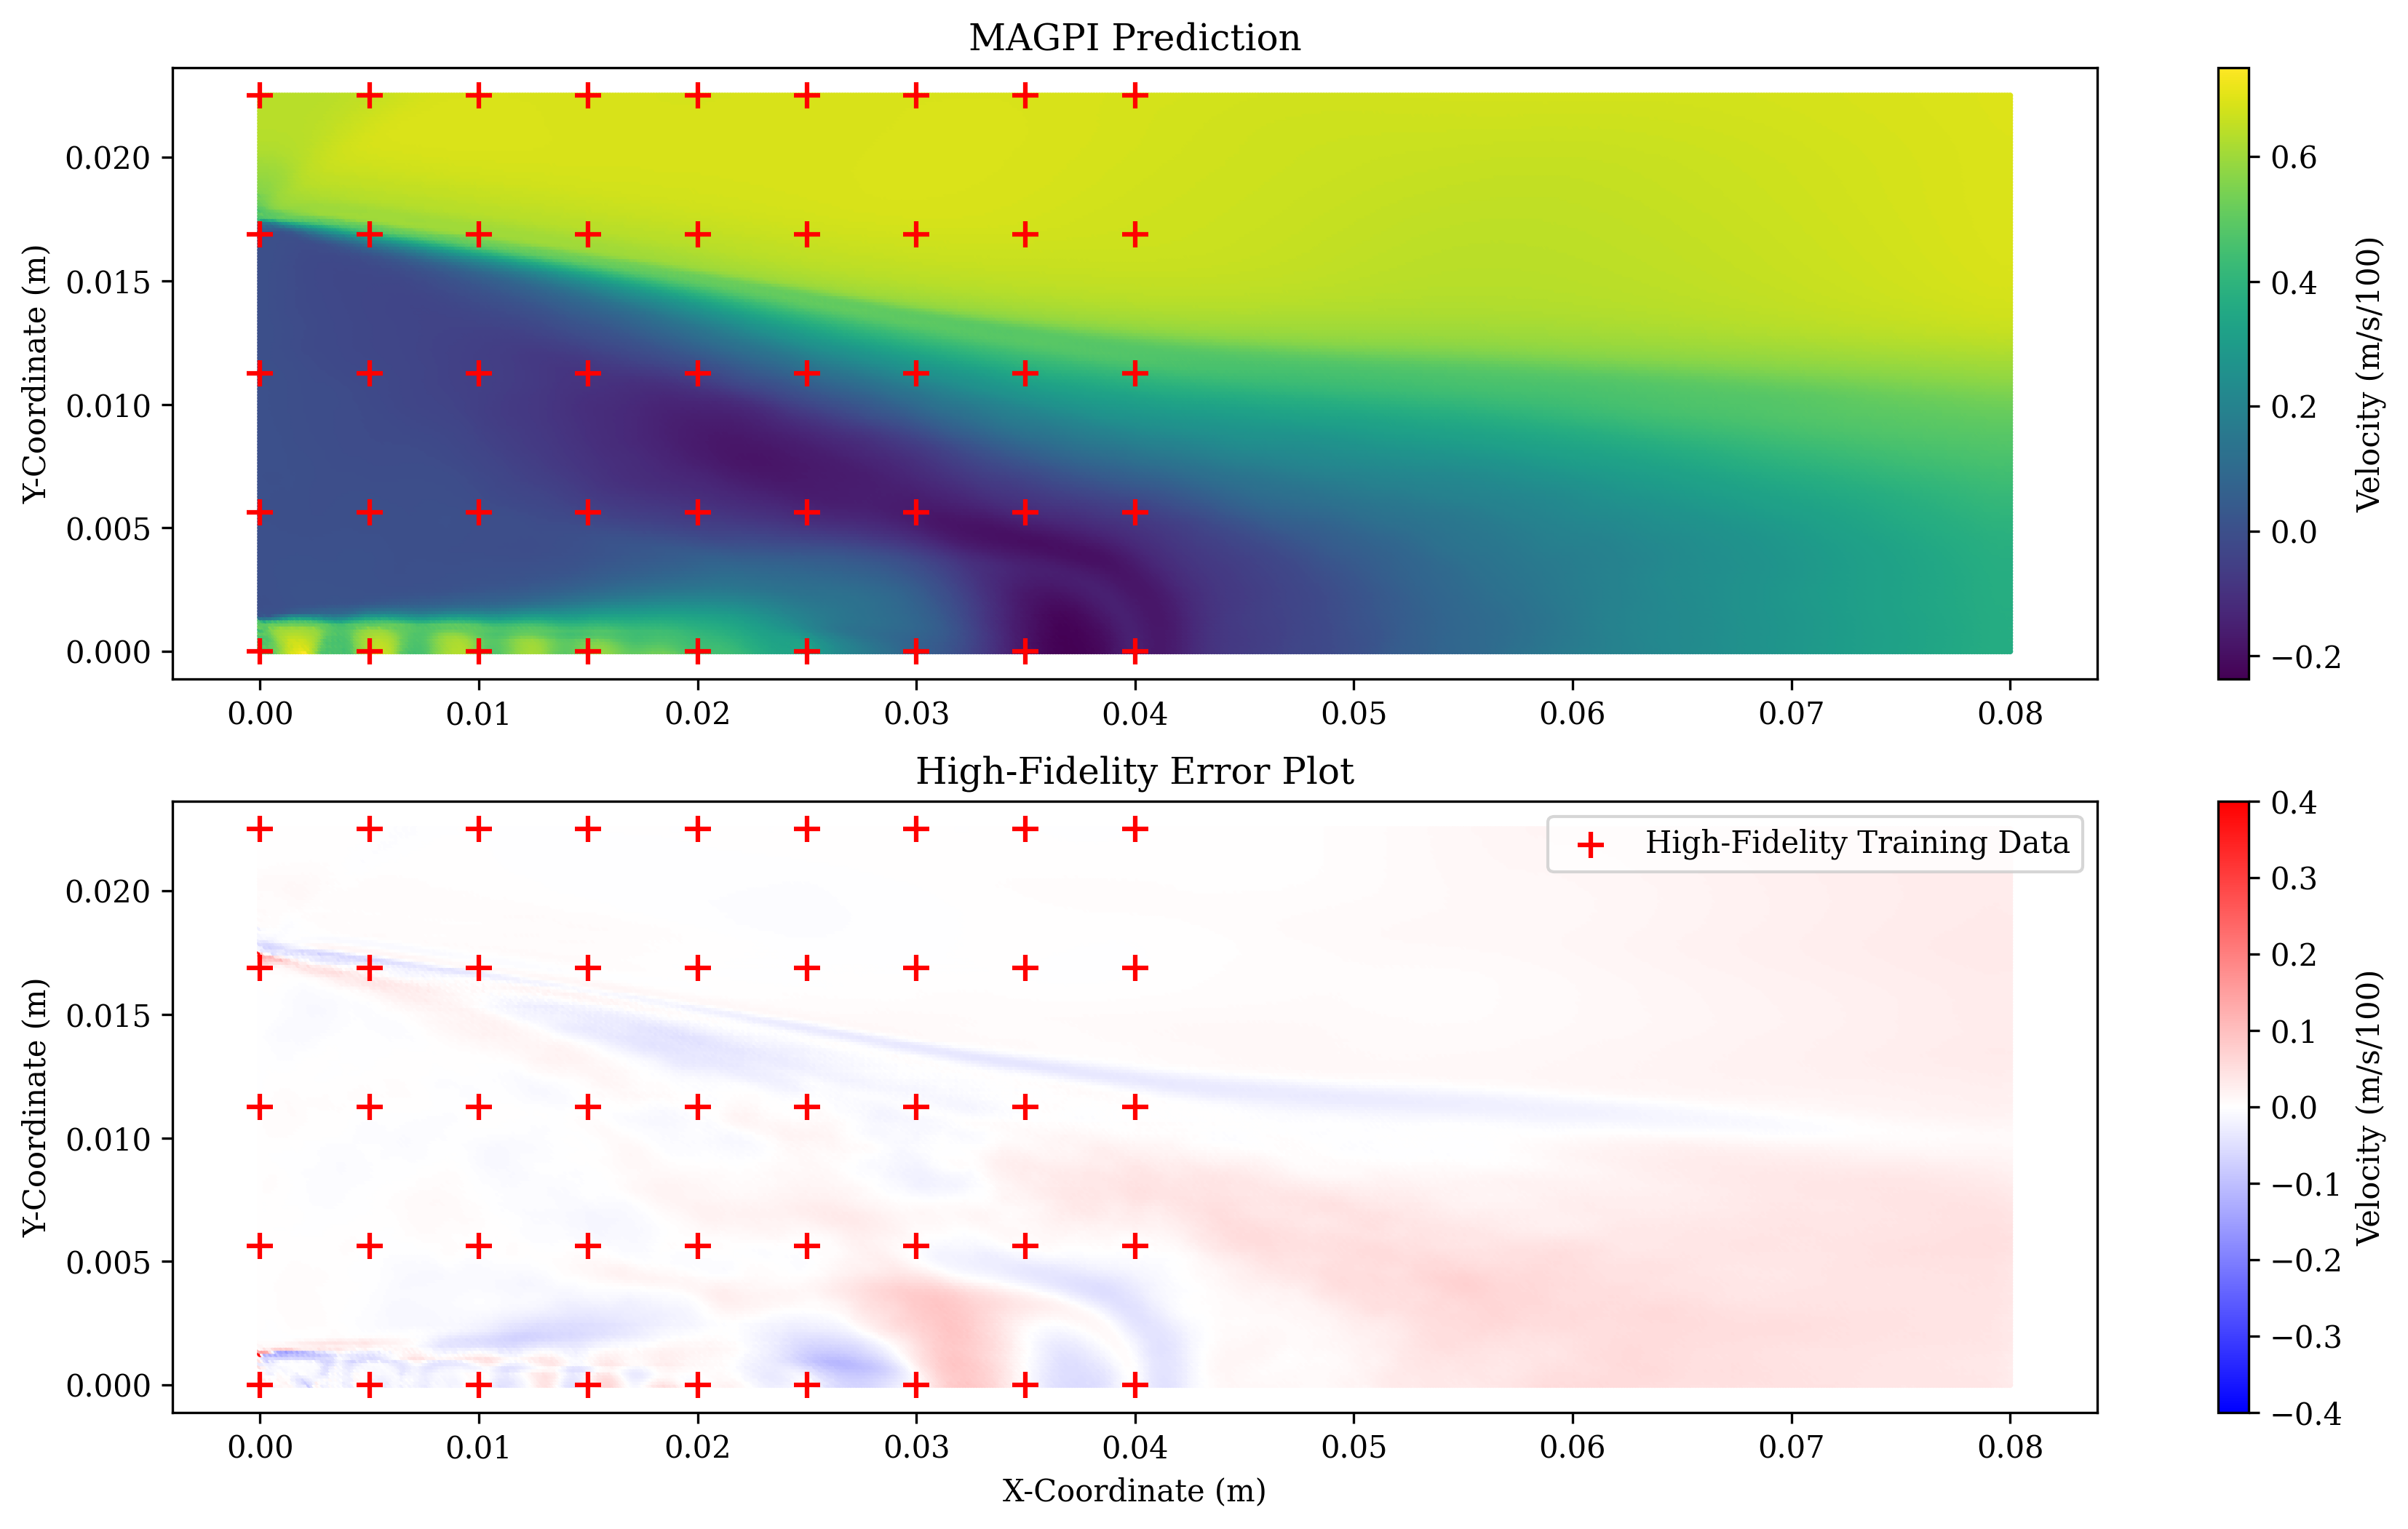

In [19]:
# Making predictions on test features
plt.figure(figsize=(4*ratio,4*2), dpi = 300)

plt.subplot(2,1,1)
plt.title("MAGPI Prediction")

plt.scatter(scaler.inverse_transform(Xtest)[:,0], scaler.inverse_transform(Xtest)[:,1], c = hk_mean, cmap = 'viridis', s = 1.0)
plt.colorbar(label = "Velocity (m/s/100)")
plt.scatter(scaler.inverse_transform(Xtrain)[:,0], scaler.inverse_transform(Xtrain)[:,1], c = 'red', s = 75, marker = '+', label = "High-Fidelity Training Data")
plt.ylabel("Y-Coordinate (m)")

plt.subplot(2,1,2)
from matplotlib.colors import TwoSlopeNorm
diff = hk_mean - Ytest
norm = TwoSlopeNorm(vmin=-.4, vcenter=0, vmax=.4)
im = plt.scatter(scaler.inverse_transform(Xtest)[:,0], scaler.inverse_transform(Xtest)[:,1], c = hk_mean - Ytest, cmap = 'bwr', norm = norm, s = 1.0)
cbar = plt.colorbar(label = "Velocity (m/s/100)")
plt.title("High-Fidelity Error Plot")
plt.scatter(scaler.inverse_transform(Xtrain)[:,0], scaler.inverse_transform(Xtrain)[:,1], c = 'red', s = 75, marker = '+', label = "High-Fidelity Training Data")
plt.ylabel("Y-Coordinate (m)")
plt.xlabel("X-Coordinate (m)")
plt.legend()
plt.savefig("results/hk_prediction_uniform.png")

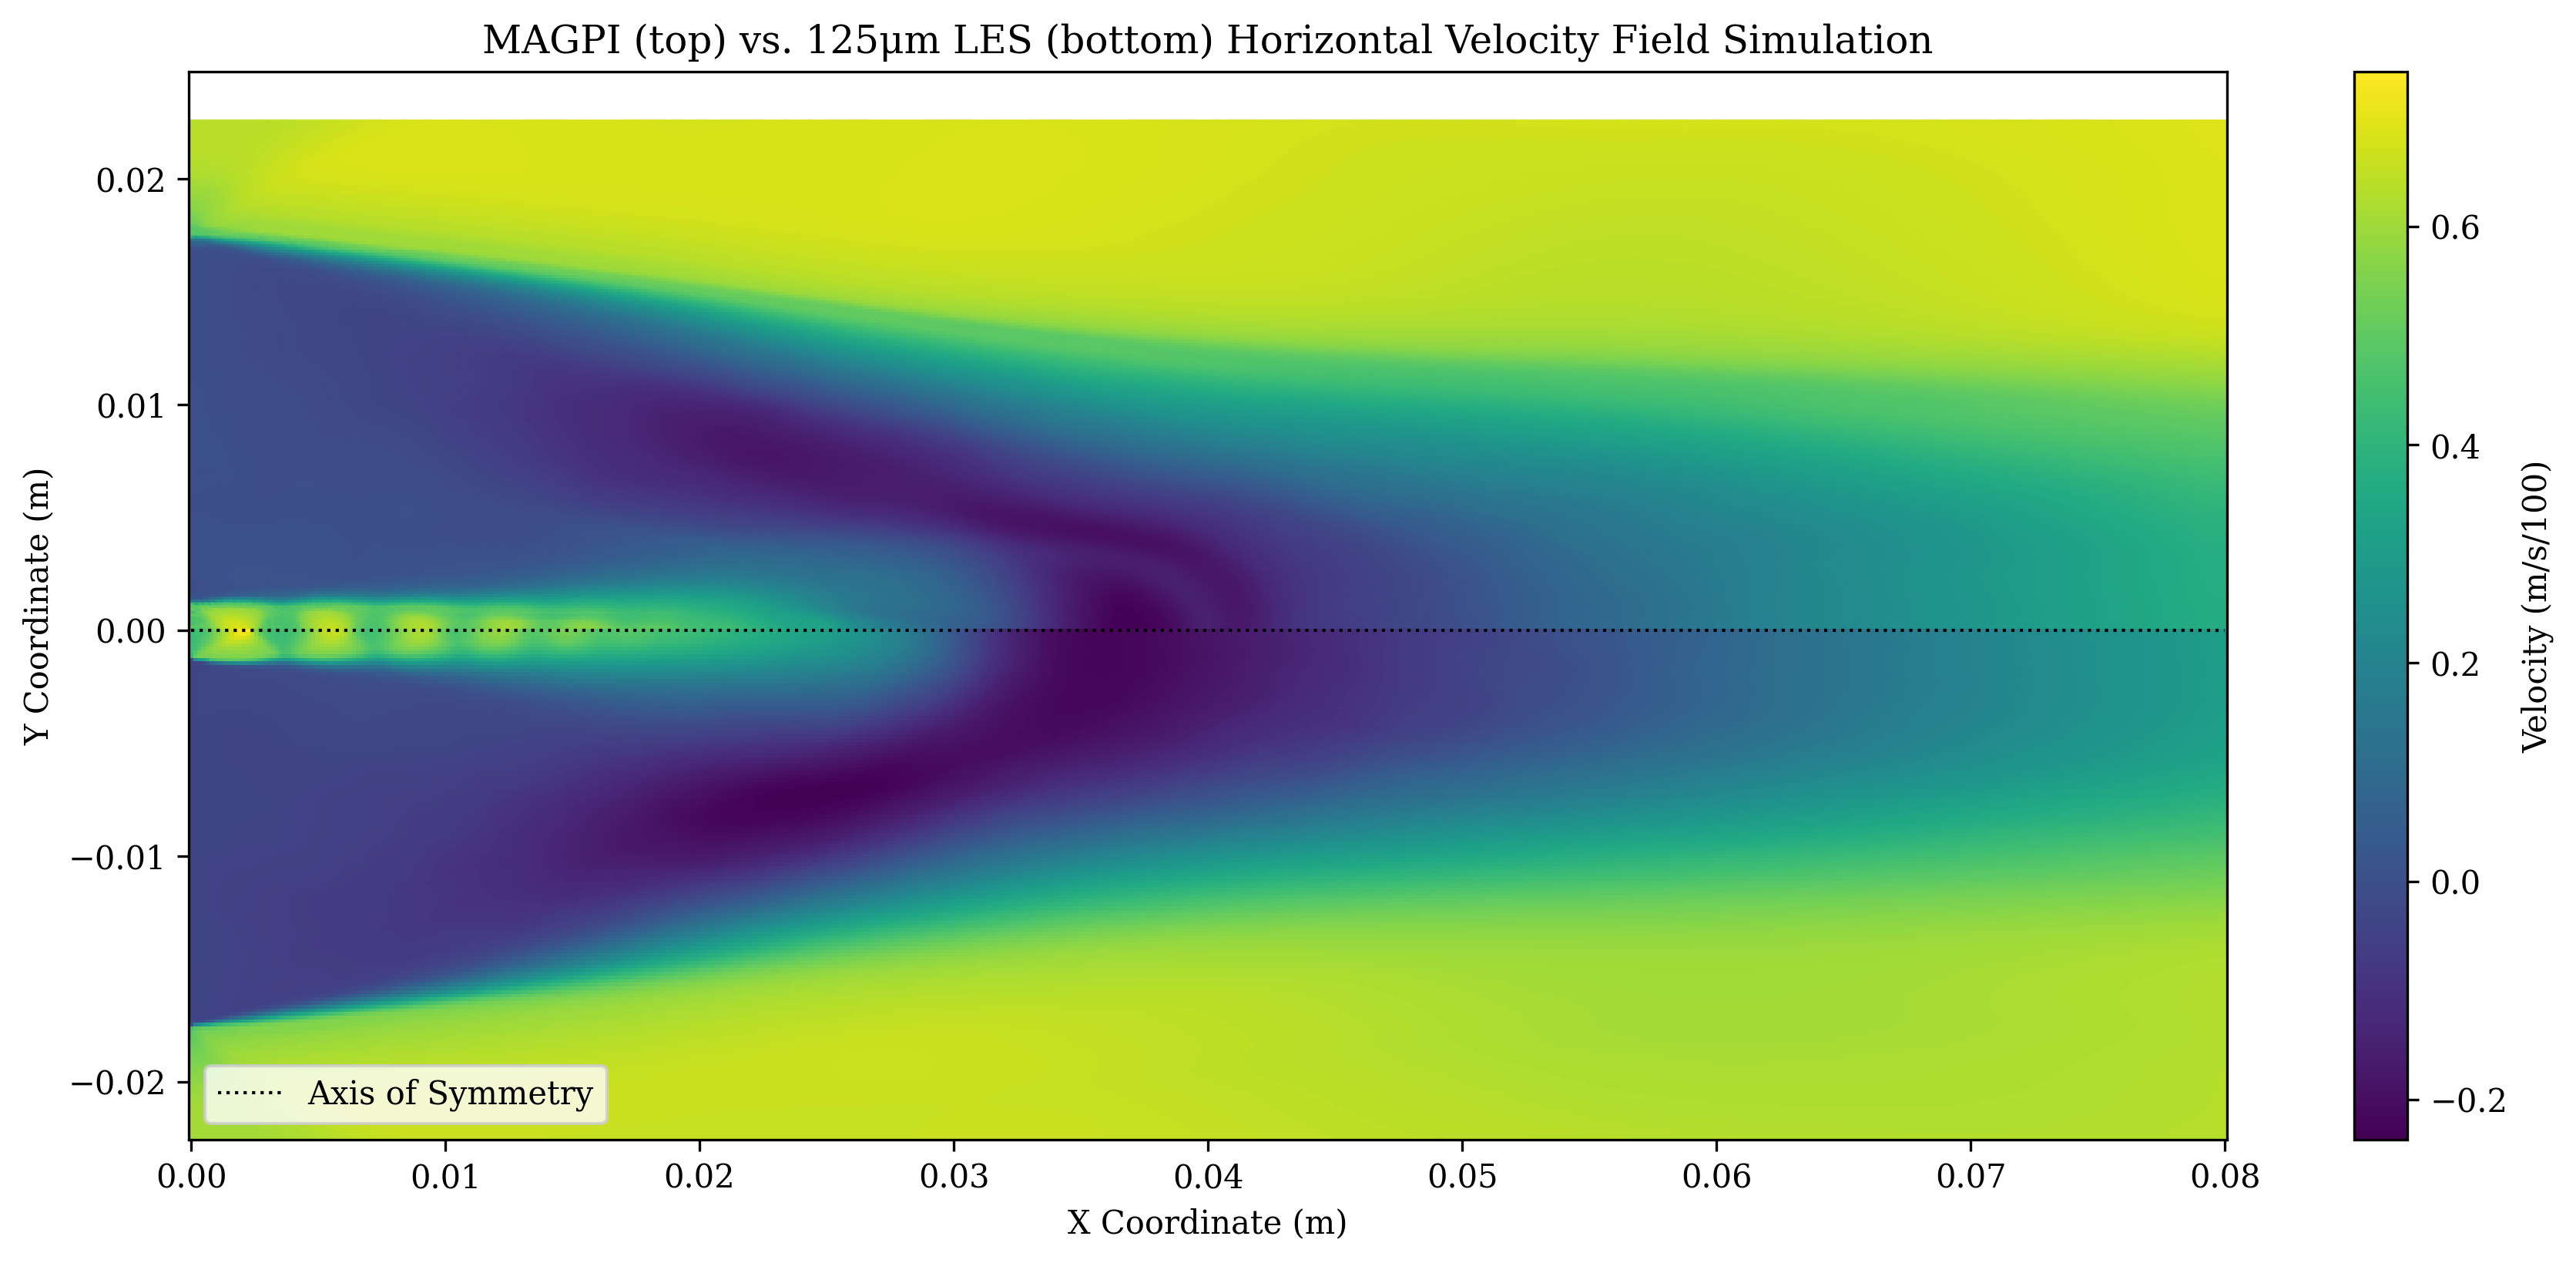

In [20]:
# Visualizing High-Fidelity training data 
plt.figure(figsize=(ratio * 4,6), dpi = 300)


plt.scatter(scaler.inverse_transform(Xtest)[:,0], scaler.inverse_transform(Xtest)[:,1], c = hk_mean, cmap = 'viridis', s = 1.0)
plt.colorbar(label = "Velocity (m/s/100)")


X, Y, Z = to_grid(temp_X, temp_Y, ratio, X_partitions = 500)
plt.pcolormesh(X, Y, Z, cmap = 'viridis')

plt.plot([0, 0.08], [0.0, 0.0], linestyle = 'dotted', linewidth =1.0, color = 'black', label = 'Axis of Symmetry')

plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title("MAGPI (top) vs. 125μm LES (bottom) Horizontal Velocity Field Simulation")
plt.legend()
plt.savefig("results/hk_vs_125_comparison.png")

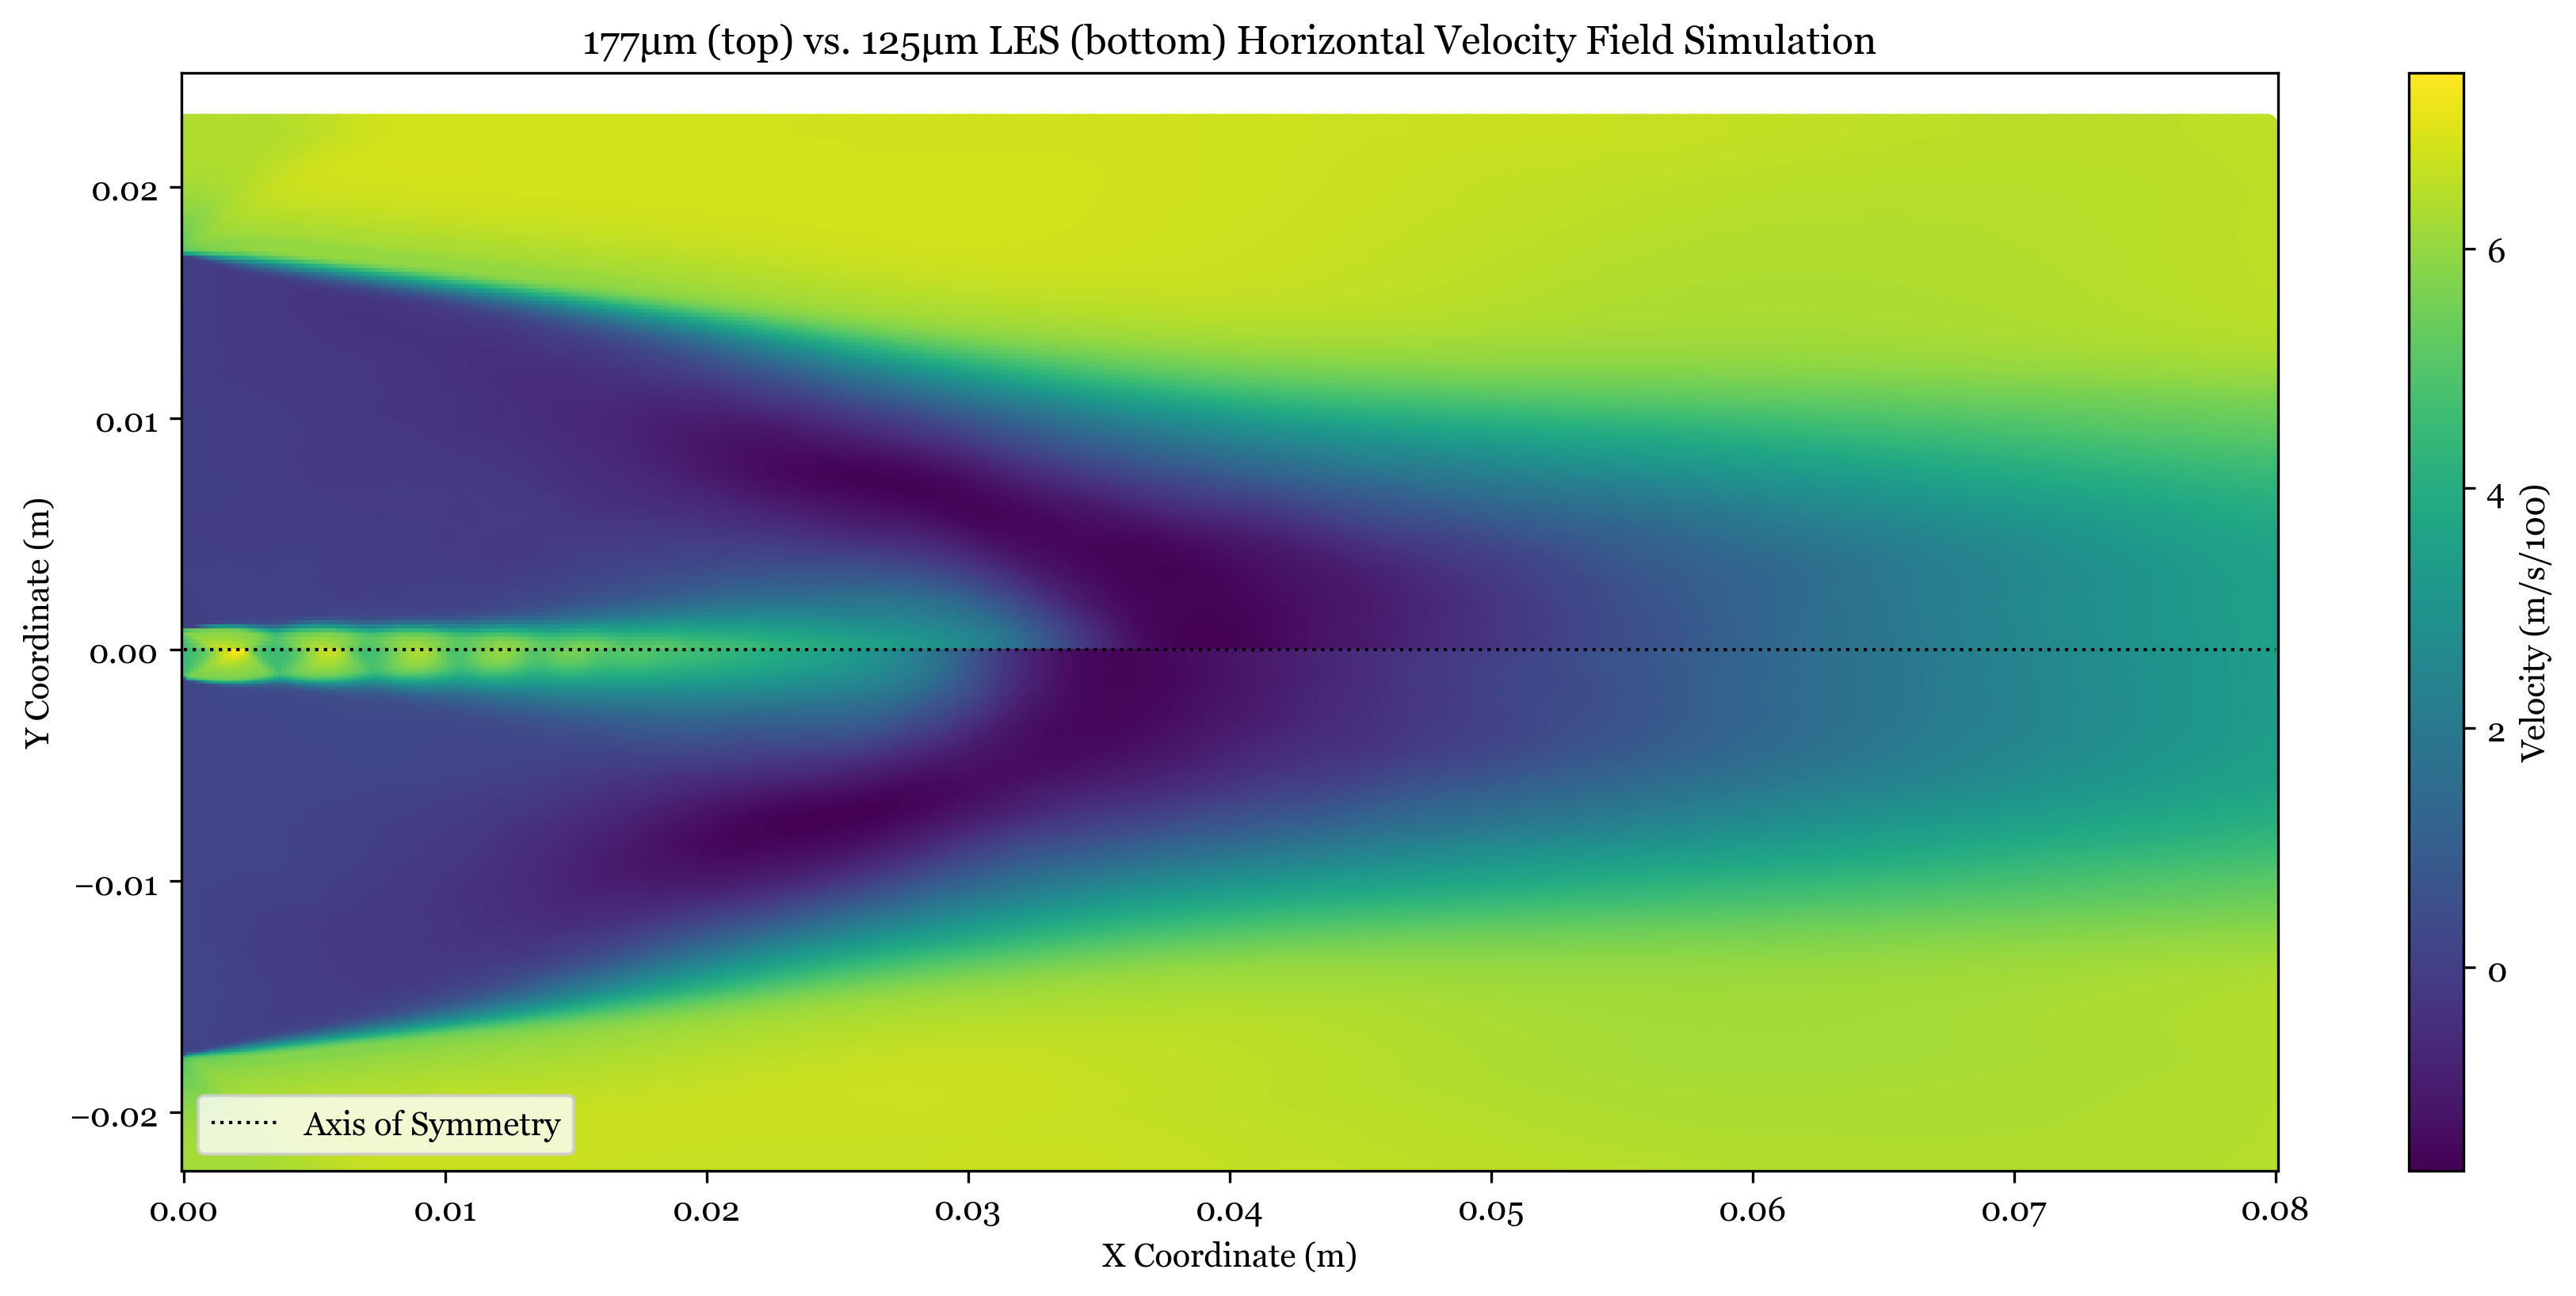

In [22]:
# Visualizing High-Fidelity training data 
plt.figure(figsize=(ratio * 4,6), dpi = 300)


plt.scatter(
    scaler.inverse_transform(data_dict[3]['X'])[:, 0],
    scaler.inverse_transform(data_dict[3]['X'])[:, 1],
    c=data_dict[3]['Y'],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label = "Velocity (m/s/100)")


X, Y, Z = to_grid(temp_X, temp_Y, N_partitions = 500)
plt.pcolormesh(X, Y, Z, cmap = 'viridis')

plt.plot([0, 0.08], [0.0, 0.0], linestyle = 'dotted', linewidth =1.0, color = 'black', label = 'Axis of Symmetry')

plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title("177μm (top) vs. 125μm LES (bottom) Horizontal Velocity Field Simulation")
plt.legend()
plt.savefig("results/177_vs_125_comparison.png")

In [21]:
hk_rmse = jnp.sqrt(jnp.mean(hk_var[grid_criterion]) + jnp.mean((hk_mean[grid_criterion] - Ytest[grid_criterion])**2))
koh_rmse = jnp.sqrt(jnp.mean(koh_var[grid_criterion] + (koh_mean[grid_criterion] - Ytest[grid_criterion])**2))
nargp_rmse = jnp.sqrt(jnp.mean(nargp_var[grid_criterion] + (nargp_mean[grid_criterion] - Ytest[grid_criterion])**2))
kr_rmse = jnp.sqrt(jnp.mean(kr_var[grid_criterion] + (kr_mean[grid_criterion] - Ytest[grid_criterion])**2))


print("Method           Grid RMSE      Grid R^2   Log ML")
print("---------------------------------------------------------------------------")
print("MAGPI          &  %.4e  &  %.4f  &  %.4f \\\\" % (hk_rmse, np.corrcoef(Ytest[grid_criterion], hk_mean[grid_criterion])[0,1], -neg_mll(magpi_model, magpi_model.p)))
print("Kennedy OH     &  %.4e  &  %.4f  &  %.4f \\\\" % (koh_rmse, np.corrcoef(Ytest[grid_criterion], koh_mean[grid_criterion])[0,1], -delta_neg_mll(delta, delta.p)))
print("NARGP          &  %.4e  &  %.4f  &  %.4f \\\\" % (nargp_rmse, np.corrcoef(Ytest[grid_criterion], nargp_mean[grid_criterion])[0,1], -neg_mll(nargp, nargp.p)))
print("Kriging        &  %.4e  &  %.4f  &  %.4f \\\\" % (kr_rmse, np.corrcoef(Ytest[grid_criterion], kr_mean[grid_criterion])[0,1], -neg_mll(kr_model, kr_model.p)))
print("177μm          &  %.4e  &  %.4f  &  -- \\\\ " %  (jnp.sqrt(MSE(Ytest[grid_criterion], test_features[grid_criterion, 5])), np.corrcoef(Ytest[grid_criterion], test_features[grid_criterion, 5])[0,1]))
print("250μm          &  %.4e  &  %.4f  &  -- \\\\ " %  (jnp.sqrt(MSE(Ytest[grid_criterion], test_features[grid_criterion, 4])), np.corrcoef(Ytest[grid_criterion], test_features[grid_criterion, 4])[0,1]))
print("500μm          &  %.4e  &  %.4f  &  -- \\\\ " %  (jnp.sqrt(MSE(Ytest[grid_criterion], test_features[grid_criterion, 3])), np.corrcoef(Ytest[grid_criterion], test_features[grid_criterion, 3])[0,1]))
print("RANSμm         &  %.4e  &  %.4f  &  -- \\\\  \\hline" %  (jnp.sqrt(MSE(Ytest[grid_criterion], test_features[grid_criterion, 2])), np.corrcoef(Ytest[grid_criterion], test_features[grid_criterion, 2])[0,1]))

Method           Grid RMSE      Grid R^2   Log ML
---------------------------------------------------------------------------
MAGPI          &  2.2556e-02  &  0.9983  &  138.9410 \\
Kennedy OH     &  1.0375e-01  &  0.9969  &  -1337.5680 \\
NARGP          &  2.9840e-01  &  0.9406  &  13.3831 \\
Kriging        &  1.0567e-01  &  0.9562  &  28.7939 \\
177μm          &  4.1232e-02  &  0.9921  &  -- \\ 
250μm          &  7.8781e-02  &  0.9705  &  -- \\ 
500μm          &  1.1332e-01  &  0.9392  &  -- \\ 
RANSμm         &  6.7716e-02  &  0.9782  &  -- \\  \hline


In [26]:
# Selecting only the points on the jet
jet_criterion = (Xtest[:,1] == Xtest[:,1].min()) # & (scaler.inverse_transform(Xtest)[:,0] <= (x_partitions-1) * grid_spacing)
Xjet, Yjet, Fjet = Xtest[jet_criterion,:], Ytest[jet_criterion], test_features[jet_criterion, :]

Xtrain_jet, Ytrain_jet, Ftrain_jet = Xtrain[Xtrain[:,1] == Xtrain[:,1].min(),:], Ytrain[Xtrain[:,1] == Xtrain[:,1].min()], train_features[Xtrain[:,1] == Xtrain[:,1].min(), :]